### 第 3 章 有模型与无模型强化学习


#### 核心区别

有模型和无模型强化学习的最大区别：智能体（Agent）是否试图去理解和预测真实世界的"物理规律"。

这里的"模型"（Model）并不是指神经网络模型，而是指**环境的动力学模型**，也就是我们之前推导中用到的：
- **状态转移概率** $P(s'|s,a)$
- **奖励函数** $R(s,a)$

![有模型 vs 无模型对比](images/ch03_model_based_vs_model_free.png)

当马尔可夫决策过程的模型未知或者模型很大时，我们可以使用无模型强化学习的方法。无模型强化学习方法没有获取环境的状态转移和奖励函数，而是让智能体与环境进行交互，采集大量的轨迹数据，智能体从轨迹中获取信息来改进策略，从而获得更多的奖励。


#### 3.1 有模型强化学习（Model-Based RL）

**核心思想**：已知或先学习环境的动力学模型 $\mathcal{M} = \{p(s'|s,a), R(s,a)\}$，通过在脑海中"推演规划"来寻找最优策略，而不需要在真实世界中付出高昂的试错代价。

**理论基础**：

有模型强化学习的核心是利用**贝尔曼方程**（Bellman Equation）进行动态规划。贝尔曼方程建立了当前状态价值与后继状态价值之间的递归关系，使得我们可以通过迭代计算来求解最优策略。

**两类贝尔曼方程**：

1. **贝尔曼期望方程**（用于策略评估）：
   $$V_\pi(s) = \sum_{a} \pi(a|s) \left[ R(s,a) + \gamma \sum_{s'} p(s'|s,a) V_\pi(s') \right]$$

2. **贝尔曼最优方程**（用于寻找最优策略）：
   $$V^*(s) = \max_a \left[ R(s,a) + \gamma \sum_{s'} p(s'|s,a) V^*(s') \right]$$

> **关键区别**：期望方程对动作求加权平均（$\sum_a \pi(a|s)$），最优方程对动作求最大值（$\max_a$）。


##### 3.1.1 动态规划（Dynamic Programming, DP）

**定义**：动态规划是一种通过将复杂问题分解为更简单的子问题来求解的算法范式。在强化学习中，DP 利用贝尔曼方程的递归结构，通过迭代更新来计算最优价值函数和最优策略。

**DP 的两个关键性质**：

1. **最优子结构**（Optimal Substructure）：最优策略的子策略也是最优的
2. **重叠子问题**（Overlapping Subproblems）：同一个状态的价值会被多次计算

**DP 的前提条件**：

- 完全已知的环境模型：$p(s'|s,a)$ 和 $R(s,a)$
- 有限的状态空间和动作空间
- 马尔可夫性：下一状态只依赖于当前状态和动作

**基于动态规划的强化学习算法**：

1. **策略迭代**（Policy Iteration）：交替执行策略评估和策略提升
2. **价值迭代**（Value Iteration）：直接迭代贝尔曼最优方程

两者的区别在于：
- **策略迭代**：每次完整评估一个策略（内层循环直到收敛），再提升策略
- **价值迭代**：每次只做一步评估就立刻提升（相当于策略评估只迭代一次）


**1. 策略迭代（Policy Iteration）**

**算法思想**：从任意策略 $\pi_0$ 出发，交替执行策略评估和策略提升，直到策略不再改变。

---

**策略评估（Policy Evaluation）**

给定策略 $\pi$，计算其状态价值函数 $V_\pi(s)$。利用贝尔曼期望方程进行迭代：

$$V_{\pi}^{k+1}(s) = \sum_{a \in \mathcal{A}} \pi(a \mid s) \cdot \left(R(s, a) + \gamma \sum_{s' \in \mathcal{S}} p(s' \mid s, a) \cdot V_{\pi}^{k}(s') \right)$$

这是一个**压缩映射**（Contraction Mapping），根据 Banach 不动点定理，迭代序列 $\{V_\pi^k\}$ 必然收敛到唯一的不动点 $V_\pi$。

> **收敛性保证**：当 $\gamma < 1$ 时，贝尔曼期望算子是 $\gamma$-压缩的，即：
> $$\|V^{k+1} - V_\pi\|_\infty \le \gamma \|V^k - V_\pi\|_\infty$$
> 这保证了指数级收敛速度。

---

**策略提升（Policy Improvement）**

根据当前价值函数 $V_\pi$，构造一个贪心策略 $\pi'$：

$$\pi'(s) = \arg\max_a Q_\pi(s,a) = \arg\max_a \left[ R(s,a) + \gamma \sum_{s' \in \mathcal{S}}p(s' \mid s, a)V_\pi(s') \right]$$

**策略改进定理**（Policy Improvement Theorem）保证：

$$V_{\pi'}(s) \ge V_{\pi}(s), \quad \forall s \in \mathcal{S}$$

**证明思路**：

$$V_\pi(s) \le Q_\pi(s, \pi'(s)) = \mathbb{E}_{\pi'}[R_{t+1} + \gamma V_\pi(S_{t+1}) | S_t=s]$$
$$\le \mathbb{E}_{\pi'}[R_{t+1} + \gamma Q_\pi(S_{t+1}, \pi'(S_{t+1})) | S_t=s]$$
$$\le \mathbb{E}_{\pi'}[R_{t+1} + \gamma R_{t+2} + \gamma^2 V_\pi(S_{t+2}) | S_t=s]$$
$$\le \cdots \le V_{\pi'}(s)$$

---

**策略迭代的收敛性**

策略迭代生成的策略序列 $\pi_0, \pi_1, \pi_2, \dots$ 满足：

$$V_{\pi_0}(s) \le V_{\pi_1}(s) \le V_{\pi_2}(s) \le \cdots \le V^*(s)$$

由于状态空间有限，价值函数单调递增且有上界，因此必在有限步内收敛到最优策略 $\pi^*$。

![策略迭代流程](images/ch03_policy_iteration_flow.png)


**策略迭代算法伪代码**

```
随机初始化策略 π(s) 和价值函数 V(s)

# 策略评估阶段
While Δ > θ do:  (策略评估循环)
    Δ ← 0
    对于每一个状态 s ∈ S:
        v ← V(s)
        V(s) ← Σ_a π(a|s)[R(s,a) + γ Σ_s' p(s'|s,a)V(s')]
        Δ ← max(Δ, |v - V(s)|)
end while

# 策略提升阶段
π_old ← π
对于每一个状态 s ∈ S:
    π(s) ← argmax_a [R(s,a) + γ Σ_s' p(s'|s,a)V(s')]

若 π_old = π，则算法终止并返回 V 和 π
否则转到策略评估循环
```


In [ ]:
import numpy as np
import copy

class CliffWalkingEnv:
    """悬崖寻路环境模型 (提供完全的上帝视角: 状态转移和奖励)"""
    def __init__(self):
        self.rows = 4
        self.cols = 12
        self.start_state = (3, 0)
        self.goal_state = (3, 11)
        
        # 悬崖区域: (3, 1) 到 (3, 10)
        self.cliff = [(3, i) for i in range(1, 11)]
        
        # 动作空间: 0:上, 1:下, 2:左, 3:右
        self.actions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        self.action_symbols = ['↑', '↓', '←', '→']
        self.state = self.start_state

    def reset(self):
        self.state = self.start_state
        return self.state

    def is_terminal(self, state):
        return state == self.goal_state
    
    def step_model(self, state, action_index):
        """
        环境动力学模型(P, R)
        输入当前状态和动作，返回下一状态和奖励
        由于是确定性的，所以返回唯一结果，无需返回概率分布
        """
        if self.is_terminal(state):
            return state, 0, True
        
        r, c = state
        dr, dc = self.actions[action_index]
        next_r, next_c = r + dr, c + dc

        # 撞墙 -> 停留原地
        if next_r < 0 or next_r >= self.rows or next_c < 0 or next_c >= self.cols:
            next_r, next_c = r, c

        next_state = (next_r, next_c)
        
        # 掉入悬崖，返回起点，奖励为 -100
        if next_state in self.cliff:
            return self.start_state, -100, False
        
        # 到达终点
        if next_state == self.goal_state:
            return next_state, -1, True
        
        return next_state, -1, False


In [ ]:
class PolicyIteration:
    def __init__(self, env, gamma=1.0, theta=1e-4):
        self.env = env
        self.gamma = gamma
        self.theta = theta

        # 随机初始化价值函数和策略
        self.V = np.zeros((env.rows, env.cols))
        # 初始化为随机策略，每个状态下4个动作的概率都是0.25
        self.pi = np.ones((env.rows, env.cols, 4)) / 4.0

    def evaluate_policy(self):
        """策略评估阶段"""
        while True:
            delta = 0
            new_V = np.copy(self.V)

            for r in range(self.env.rows):
                for c in range(self.env.cols):
                    state = (r, c)
                    if self.env.is_terminal(state):
                        continue

                    v = self.V[r, c]
                    v_sum = 0.0
                    for a in range(4):
                        action_prob = self.pi[r, c, a]
                        if action_prob == 0:
                            continue
                        next_state, reward, _ = self.env.step_model(state, a)
                        future_v = self.V[next_state[0], next_state[1]]
                        v_sum += action_prob * (reward + self.gamma * future_v)
                    
                    new_V[r, c] = v_sum
                    delta = max(delta, abs(v - new_V[r, c]))
            
            self.V = new_V
            if delta < self.theta:
                break

    def improve_policy(self):
        """策略改进阶段"""
        old_pi = np.copy(self.pi)

        for r in range(self.env.rows):
            for c in range(self.env.cols):
                state = (r, c)
                if self.env.is_terminal(state):
                    continue
                
                q_values = np.zeros(4)
                for a in range(4):
                    next_state, reward, _ = self.env.step_model(state, a)
                    q_values[a] = reward + self.gamma * self.V[next_state[0], next_state[1]]
                
                best_action = np.argmax(q_values)
                self.pi[r, c] = 0.0
                self.pi[r, c, best_action] = 1.0

        return np.array_equal(old_pi, self.pi)
    
    def train(self):
        iteration = 1
        while True:
            self.evaluate_policy()
            is_stable = self.improve_policy()
            print(f'完成第 {iteration} 次完整的评估+改进迭代')
            if is_stable:
                print("策略不再改变，收敛到全局最优解")
                break
            iteration += 1

    def render_policy(self):
        print("\n===== 最优策略地图 =====")
        for r in range(self.env.rows):
            row_str = ""
            for c in range(self.env.cols):
                state = (r, c)
                if state == self.env.goal_state:
                    row_str += " G "
                elif state in self.env.cliff:
                    row_str += " C "
                else:
                    best_action = np.argmax(self.pi[r, c])
                    row_str += f" {self.env.action_symbols[best_action]} "
            print(row_str)

# 运行策略迭代
if __name__ == "__main__":
    env = CliffWalkingEnv()
    agent = PolicyIteration(env, gamma=0.9)
    agent.train()
    agent.render_policy()


**2. 价值迭代（Value Iteration）**

**核心思想**：直接迭代贝尔曼最优方程，把"评估"和"改进"融为一体

价值迭代抛弃了显式的策略，只维护一个价值函数 $V(s)$。每次更新时，直接假设下一步会选择最优动作：

$$V^{k+1}(s) = \max_{a \in \mathcal{A}} \left[ R(s,a) + \gamma \sum_{s' \in \mathcal{S}} p(s' \mid s,a) \cdot V^k(s') \right]$$

**与策略迭代的关系**：

价值迭代可以看作是策略迭代的特殊情况，其中策略评估只进行**一次迭代**就立刻进行策略提升。

---

**收敛性证明**

定义贝尔曼最优算子 $\mathcal{T}$：

$$[\mathcal{T}V](s) = \max_a \left[ R(s,a) + \gamma \sum_{s'} p(s'|s,a) V(s') \right]$$

**定理**：贝尔曼最优算子 $\mathcal{T}$ 是 $\gamma$-压缩映射。

**证明**：对于任意两个价值函数 $V_1$ 和 $V_2$，

$$\begin{aligned}
|[\mathcal{T}V_1](s) - [\mathcal{T}V_2](s)| 
&= \left| \max_a \mathbb{E}[R + \gamma V_1(S')] - \max_a \mathbb{E}[R + \gamma V_2(S')] \right| \\
&\le \max_a \left| \mathbb{E}[\gamma V_1(S') - \gamma V_2(S')] \right| \\
&\le \gamma \max_a \mathbb{E}[|V_1(S') - V_2(S')|] \\
&\le \gamma \|V_1 - V_2\|_\infty
\end{aligned}$$

因此 $\|\mathcal{T}V_1 - \mathcal{T}V_2\|_\infty \le \gamma \|V_1 - V_2\|_\infty$，即 $\mathcal{T}$ 是压缩映射。

根据 Banach 不动点定理，$\mathcal{T}$ 有唯一不动点 $V^*$，且迭代序列 $V^{k+1} = \mathcal{T}V^k$ 必收敛到 $V^*$。

**收敛速度**：

$$\|V^k - V^*\|_\infty \le \gamma^k \|V^0 - V^*\|_\infty$$

这表明价值迭代以**指数速度**收敛到最优价值函数。

---

**策略迭代 vs 价值迭代**

| 特性 | 策略迭代 | 价值迭代 |
|------|---------|--------|
| 每轮迭代 | 完整评估 + 提升 | 一步评估 + 提升 |
| 迭代次数 | 较少（通常 < 10） | 较多 |
| 每次迭代成本 | 高（需要求解线性方程组） | 低（只需一次扫描） |
| 总计算量 | 取决于具体问题 | 取决于具体问题 |
| 收敛保证 | 有限步收敛 | 指数速度收敛 |


**价值迭代算法伪代码**

```
# 初始化
随机初始化价值函数 V(s)

# 合并了价值评估和策略提升
While Δ > θ do:
    Δ ← 0
    对于每一个状态 s ∈ S:
        v ← V(s)
        V(s) ← max_a [R(s,a) + γ Σ_s' p(s'|s,a)·V(s')]
        Δ ← max(Δ, |v - V(s)|)
end while

# 提取最优策略
对于每一个 s ∈ S:
    π(s) ← argmax_a [R(s,a) + γ Σ_s' p(s'|s,a)V(s')]

返回 V(s) 和 π(s)
```


In [ ]:
class ValueIteration:
    def __init__(self, env, gamma=1.0, theta=1e-4):
        self.env = env
        self.gamma = gamma
        self.theta = theta

        # 初始化价值函数，不初始化策略
        self.V = np.zeros((self.env.rows, self.env.cols))
        self.pi = np.zeros((self.env.rows, self.env.cols, 4), dtype=float)

    def train(self):
        iteration = 1
        while True:
            delta = 0.0
            new_V = np.copy(self.V)  # 同步更新

            for r in range(self.env.rows):
                for c in range(self.env.cols):
                    state = (r, c)
                    if self.env.is_terminal(state):
                        continue
                    
                    v = self.V[r, c]
                    max_qvalue = -float('inf')
                    
                    for a in range(4):
                        next_state, reward, _ = self.env.step_model(state, a)
                        q_value = reward + self.gamma * self.V[next_state[0], next_state[1]]
                        if q_value > max_qvalue:
                            max_qvalue = q_value

                    new_V[r, c] = max_qvalue
                    delta = max(delta, abs(v - new_V[r, c]))
            
            self.V = new_V
            print(f'完成第 {iteration} 次价值迭代')

            if delta < self.theta:
                print(f"价值迭代收敛！共耗时 {iteration} 轮")
                break
            iteration += 1
        
        self.extract_policy()

    def extract_policy(self):
        """从价值函数中提取最优策略"""
        for r in range(self.env.rows):
            for c in range(self.env.cols):
                state = (r, c)
                if self.env.is_terminal(state):
                    continue
                
                best_action = -1
                best_q_value = -float('inf')
                
                for a in range(4):
                    next_state, reward, _ = self.env.step_model(state, a)
                    q_value = reward + self.gamma * self.V[next_state[0], next_state[1]]
                    
                    if q_value > best_q_value:
                        best_q_value = q_value
                        best_action = a
                
                self.pi[r, c] = 0
                self.pi[r, c, best_action] = 1

    def render_policy(self):
        print("\n===== 最优策略地图 =====")
        for r in range(self.env.rows):
            row_str = ""
            for c in range(self.env.cols):
                state = (r, c)
                if state == self.env.goal_state:
                    row_str += " G "
                elif state in self.env.cliff:
                    row_str += " C "
                else:
                    best_action = np.argmax(self.pi[r, c])
                    row_str += f" {self.env.action_symbols[best_action]} "
            print(row_str)

# 运行价值迭代
if __name__ == "__main__":
    env = CliffWalkingEnv()
    agent = ValueIteration(env, gamma=0.9, theta=1e-4)
    agent.train()
    agent.render_policy()
    print("\n价值函数：")
    print(agent.V)


#### 3.2 无模型强化学习（Model-Free RL）

**核心思想**：不依赖环境模型，直接通过与环境交互的真实"试错经验"来更新价值和策略。

**从有模型到无模型的转变**：

在动态规划中，我们利用已知的 $p(s'|s,a)$ 和 $R(s,a)$ 来计算期望。但在无模型方法中，我们用**采样**来替代**期望计算**：

$$\underbrace{\sum_{s'} p(s'|s,a) V(s')}_{\text{DP：精确期望}} \quad \longrightarrow \quad \underbrace{V(S')}_{\text{采样：单次观测}}$$

这个替代带来了两个后果：
1. **好处**：不再需要环境模型
2. **代价**：引入了采样噪声（方差）

无模型方法的三大流派：

| 方法 | 更新时机 | 更新目标 | 自举 |
|------|---------|---------|------|
| 蒙特卡洛（MC） | 回合结束 | 真实回报 $G_t$ | 否 |
| 时序差分（TD） | 每步 | $R + \gamma V(S')$ | 是 |
| TD(λ) | 每步 | λ-回报（加权平均） | 是 |


##### 3.2.1 蒙特卡洛方法（Monte Carlo, MC）

**基本思想**：利用完整回合的经验，通过采样估计期望

蒙特卡洛方法是一种基于**大数定律**的统计模拟方法。在强化学习中，MC 方法通过让智能体与环境交互生成完整的回合轨迹，然后用实际观测到的回报来估计状态价值。

**理论基础：大数定律**

设 $G_t^{(i)}$ 是第 $i$ 次访问状态 $s$ 后获得的回报，则根据大数定律：

$$\frac{1}{N} \sum_{i=1}^{N} G_t^{(i)} \xrightarrow{N \to \infty} \mathbb{E}[G_t | S_t = s] = V_\pi(s)$$

即样本均值依概率收敛到真实期望。

---

**蒙特卡洛方法的三大核心要素**

1. **无模型（Model-Free）**：
   - 不需要知道 $p(s'|s,a)$ 和 $R(s,a)$
   - 完全通过经验（Experience）来学习
   - 适用于模型未知或难以建模的环境

2. **基于完整回合（Episodic）**：
   - 必须等回合结束才能计算回报 $G_t$
   - 只适用于有终止状态的任务
   - 无法用于持续性任务（Continuing tasks）

3. **基于平均回报进行价值估计**：
   - 用样本均值估计期望：$V(s) \approx \frac{1}{N} \sum_{i=1}^{N} G_t^{(i)}$
   - 估计是**无偏的**：$\mathbb{E}[\hat{V}(s)] = V_\pi(s)$
   - 但方差较大：$\text{Var}(\hat{V}(s)) = \frac{\text{Var}(G_t)}{N}$

---

**First-visit MC vs Every-visit MC**

- **First-visit MC**：每个回合中，状态 $s$ 第一次出现后的 $G_t$ 才纳入平均
  - 样本独立同分布（i.i.d.）
  - 根据大数定律，保证收敛到 $V_\pi(s)$

- **Every-visit MC**：只要经过 $s$，无论第几次，其后续回报都纳入平均
  - 样本不独立（同一回合内的多次访问相关）
  - 但仍然收敛到 $V_\pi(s)$（可以证明）

两者在实践中性能相近，First-visit 更常用因为理论分析更简单。


**1. 蒙特卡洛策略评估（MC Prediction）**

在这个阶段，智能体的目标非常单一：给定一个固定的策略 $\pi$，测算出它到底有多好。它是一个纯粹的观察者和记录者。

- **输入**：一个固定的策略以及可以交互的环境
- **输出**：状态价值函数 $V_{\pi}(s)$ 或者动作价值函数 $Q_{\pi}(s,a)$
- **核心逻辑**：大数定理
  - 智能体遵循策略在环境中运行成千上万个回合
  - 计算每个状态在各个回合中产生的实际回报 $G_t$
  - 求经验平均值：$V(s) = \text{Average}(G_t)$
  - 只要回合数足够多，这个平均值就会无限逼近数学期望

- **工程细节分支**：
  - **首次访问（First-visit MC）**：每个回合中，状态 $s$ 第一次出现后的 $G_t$ 才纳入平均
  - **每次访问（Every-visit MC）**：只要经过 $s$，无论第几次，其后续的回报都纳入平均


**2. 蒙特卡洛控制（MC Control）**

评估不是目的，找到最优策略 $\pi^*$ 才是。控制模块就是利用"评估器"给出的反馈，不断优化策略的过程。

**核心难题**：无模型下的决策盲区

- 如果只评估 $V(s)$，智能体即使知道前面有个格子价值很高，它也不知道当前该选"上下左���"哪个动作才能走过去（因为它没有环境的动态概率模型 $p(s'|s,a)$）
- **破局关键**：必须评估 $Q(s,a)$。有了 $Q$ 表，决策就变成了极其简单的查表：$\pi(s)=\arg\max_a Q(s,a)$

**核心机制**：广义策略迭代（Generalized Policy Iteration, GPI）
 

与动态规划中的策略迭代类似，MC 控制也是交替执行"评估"与"改进"：
1. **评估（Evaluation）**：用当前策略 $\pi$ 跑完整回合，更新 $Q(s,a)$
2. **改进（Improvement）**：根据新的 $Q$ 表，让策略变得更"贪心"

**探索的保障伞**：$\epsilon$-贪心策略（$\epsilon$-greedy）

纯贪心策略会导致"只利用不探索"，永远无法发现更好的动作。$\epsilon$-贪心策略保证所有 $(s,a)$ 都有机会被尝试：

$$\pi(a|s) = \begin{cases} 1 - \epsilon + \frac{\epsilon}{|\mathcal{A}(s)|}, & \text{if } a = \arg\max_a Q(s,a) \\ \frac{\epsilon}{|\mathcal{A}(s)|}, & \text{otherwise} \end{cases}$$

其中 $|\mathcal{A}(s)|$ 是可选动作的总数。

- 有 $1-\epsilon$ 的概率选择当前 $Q$ 值最大的动作（**利用** Exploitation）
- 有 $\epsilon$ 的概率均匀随机选择任何一个动作（**探索** Exploration）


**3. 增量式更新**

随着回合数越来越多，如果每次都把所有历史数据拿出来重新算一遍平均值，内存和算力都会崩溃。增量更新提供了数学上的优雅解法。

**标准增量公式**：

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \frac{1}{N(S_t, A_t)}[G_t - Q(S_t, A_t)]$$

其中 $N(S_t, A_t)$ 是状态-动作对 $(S_t, A_t)$ 被访问的次数。步长 $\frac{1}{N}$ 随着访问次数增加而减小，更新越来越谨慎。

> 这个公式等价于求所有历史 $G_t$ 的算术平均值，但只需 $O(1)$ 的内存。

**实战进化版**：常数学习率（Constant-$\alpha$ MC）

在 MC 控制过程中，策略在不断进化，早期数据和后期数据的含金量不同。采用固定学习率 $\alpha \in (0,1]$：

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha[G_t - Q(S_t, A_t)]$$

展开后可以看到，这是一种**指数加权平均**：

$$Q_n = (1-\alpha)^n Q_0 + \sum_{i=1}^{n} \alpha(1-\alpha)^{n-i} G_i$$

越久远的 $G_i$，其权重 $\alpha(1-\alpha)^{n-i}$ 越小（指数衰减），使算法更看重近期经验，适应策略的变化。


**4. MC 控制伪代码**

```
# 初始化
For 所有的状态 s 和动作 a:
    Q(s, a) <- 任意初始值 (例如 0)
    Returns(s, a) <- 空列表 []
    pi <- 基于 Q 的任意一个 epsilon-贪心策略

# 训练阶段
Loop 每一个 Episode:
    # 1. 采样阶段
    使用当前策略 pi 生成一条完整轨迹:
    S_0, A_0, R_1, S_1, A_1, R_2, ..., S_{T-1}, A_{T-1}, R_T
    G <- 0

    # 2. 评估与改进阶段 (沿轨迹倒推)
    Loop 每一步 t = T-1, T-2, ..., 0:
        G <- gamma * G + R_{t+1}

        If (S_t, A_t) 在时刻 t 之前没有出现过 (First-Visit):
            # 策略评估
            Returns(S_t, A_t).append(G)
            Q(S_t, A_t) <- Average(Returns(S_t, A_t))

            # 策略改进
            A_star <- argmax_a Q(S_t, a)
            For 所有动作 a:
                If a == A_star:
                    pi(a|S_t) <- 1 - epsilon + epsilon/|A|
                Else:
                    pi(a|S_t) <- epsilon/|A|
```


In [ ]:
class MonteCarloControl:
    def __init__(self, env, epsilon=0.1, gamma=0.9, num_episode=5000):
        self.env = env
        self.epsilon = epsilon
        self.gamma = gamma
        self.num_episode = num_episode
        self.Q = np.zeros((self.env.rows, self.env.cols, 4))
        self.N = np.zeros((self.env.rows, self.env.cols, 4))
        self.pi = np.ones((self.env.rows, self.env.cols, 4)) * 0.25

    def generate_episode(self, max_steps=500):
        """生成一条完整的交互轨迹"""
        episode = []
        state = self.env.reset()
        for _ in range(max_steps):
            if self.env.is_terminal(state):
                break
            r, c = state
            action = np.random.choice(4, p=self.pi[r, c])
            next_state, reward, done = self.env.step_model(state, action)
            episode.append((state, action, reward))
            state = next_state
            if done:
                break
        return episode
    
    def train(self):
        for ep in range(self.num_episode):
            episode = self.generate_episode()
            if not episode:
                continue
            G = 0
            current_epsilon = self.epsilon * max(0.01, (1 - ep / self.num_episode))
            for t in reversed(range(len(episode))):
                state, action, reward = episode[t]
                G = self.gamma * G + reward
                # First-visit 检查
                previous_sa = [(s, a) for s, a, _ in episode[0:t]]
                if (state, action) not in previous_sa:
                    r, c = state
                    self.N[r, c, action] += 1
                    self.Q[r, c, action] += (G - self.Q[r, c, action]) * 0.1

                    # 策略改进
                    best_action = np.argmax(self.Q[r, c])
                    for a in range(4):
                        if a == best_action:
                            self.pi[r, c, a] = 1 - current_epsilon + (current_epsilon / 4.0)
                        else:
                            self.pi[r, c, a] = (current_epsilon / 4.0)
            if (ep + 1) % 5000 == 0:
                print(f"完成 {ep + 1} 个回合的采样与学习")
        print("MC 控制训练结束！")

    def render_policy(self):
        print("\n===== MC 最优策略地图 =====")
        for r in range(self.env.rows):
            row_str = ""
            for c in range(self.env.cols):
                state = (r, c)
                if state == self.env.goal_state:
                    row_str += " G  "
                elif state in self.env.cliff:
                    row_str += " C  "
                else:
                    best_action = np.argmax(self.Q[r, c])
                    row_str += f" {self.env.action_symbols[best_action]}  "
            print(row_str)

# 运行 MC 控制
if __name__ == "__main__":
    env = CliffWalkingEnv()
    agent = MonteCarloControl(env, gamma=1, epsilon=0.1, num_episode=20000)
    agent.train()
    agent.render_policy()


**5. MC 的致命软肋：方差诅咒（Curse of Variance）**

对于 MC 方法，状态 $S_t$ 的回报是未来所有奖励的累加：

$$G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \dots + \gamma^{T-t-1} R_T$$

每一步奖励 $R$ 都是随机变量（因为动作有 $\epsilon$ 的概率乱走，环境本身也可能含有随机性）。当各步奖励的随机性相互独立时，总方差近似满足：

$$\text{Var}(G_t) \approx \text{Var}(R_{t+1}) + \gamma^2 \text{Var}(R_{t+2}) + \gamma^4 \text{Var}(R_{t+3}) + \dots$$

**步数越长，方差累加越多，总方差会持续膨胀！**

> **类比**：接力赛跑。MC 只看最终的总成绩：如果第一棒跑得极其完美，但最后一棒脚滑摔倒了，导致全队成绩垫底。MC 在复盘时会给第一棒打一个极低的分数（-100 分）。第一棒的完美表现，被后续队友的随机失误彻底淹没了。

**偏差-方差权衡**：

| 特性 | MC 方法 | TD 方法 |
|------|--------|--------|
| 偏差（Bias） | **无偏**（使用真实回报 $G_t$） | **有偏**（使用估计值 $V(S_{t+1})$） |
| 方差（Variance） | **高方差**（整条轨迹的随机性累加） | **低方差**（只依赖单步奖励） |
| 收敛速度 | 慢（需要大量回合） | 快（每步都能更新） |


![偏差-方差权衡](images/ch03_bias_variance_tradeoff.png)


##### 3.2.2 单步时序差分方法（Temporal Difference Learning, TD）

**基本思想**：结合蒙特卡洛的采样与动态规划的自举

时序差分方法是强化学习中最核心的创新之一。它结合了两种方法的优点：

- **从蒙特卡洛继承了"采样"**：不需要环境模型，从真实交互中学习
- **从动态规划继承了"自举"**：不需要等回合结束，利用后继状态的估计值来更新当前状态

---

**MC 与 TD 的更新公式对比**

两者都是在更新 $V(S_t)$，区别在于**更新目标**不同：

| 方法 | 更新公式 | 更新目标 |
|------|---------|--------|
| MC | $V(S_t) \leftarrow V(S_t) + \alpha [G_t - V(S_t)]$ | 真实回报 $G_t$ |
| TD(0) | $V(S_t) \leftarrow V(S_t) + \alpha [R_{t+1} + \gamma V(S_{t+1}) - V(S_t)]$ | TD 目标 $R_{t+1} + \gamma V(S_{t+1})$ |

**关键区别**：

- MC 使用**真实回报** $G_t = R_{t+1} + \gamma R_{t+2} + \dots + \gamma^{T-t-1} R_T$（需要等回合结束）
- TD 使用**估计回报** $R_{t+1} + \gamma V(S_{t+1})$（只需走一步，用 $V(S_{t+1})$ 代替未来的真实回报）

这种用估计值代替真实值的做法叫做**自举（Bootstrapping）**。

---

**理论性质**

| 性质 | MC | TD(0) |
|------|-----|-------|
| 无偏性 | **无偏**：$\mathbb{E}[G_t] = V_\pi(S_t)$ | **有偏**：$\mathbb{E}[R_{t+1} + \gamma V(S_{t+1})] \ne V_\pi(S_t)$（当 $V$ 不准确时） |
| 方差 | **高方差**：$G_t$ 依赖整条轨迹的随机性 | **低方差**：只依赖单步奖励和下一状态 |
| 收敛性 | 收敛到 $V_\pi$（大数定律） | 收敛到 $V_\pi$（随机近似理论） |
| 需要回合结束 | 是 | 否 |
| 适用范围 | 仅回合制任务 | 回合制和持续性任务 |

> **TD 的有偏性**：虽然 TD 目标是有偏的（因为 $V(S_{t+1})$ 本身是估计值），但随着学习的进行，$V$ 越来越准确，偏差会逐渐减小。在满足 Robbins-Monro 条件（$\sum \alpha_t = \infty$，$\sum \alpha_t^2 < \infty$）时，TD(0) 仍然保证收敛到 $V_\pi$。

---

**通俗举例**：预测驾车回家的时间

- **MC 做法**：一路开到家，看手表发现花了 45 分钟，然后更新经验
- **TD 做法**：刚开出公司 5 分钟遇到堵车，根据对剩余路程的估计（50 分钟），立刻更新总时间估计为 55 分钟

![MC vs TD 对比](images/ch03_mc_vs_td.png)


**1. TD(0) 策略评估算法**

TD(0) 的目标是：给定一个固定的策略 $\pi$，评估在这个策略下每个状态的价值 $V_\pi(s)$。

**TD 误差（TD Error）**：

$$\delta_t = R_{t+1} + \gamma V(S_{t+1}) - V(S_t)$$

这个误差衡量了"实际反馈 + 新预判"与"旧预判"之间的差距：

- **TD 目标（TD Target）**：$R_{t+1} + \gamma V(S_{t+1})$ - 走一步后的新估计
- **当前估计**：$V(S_t)$ - 走之前的旧估计
- **TD 误差**：两者之差

**更新规则**：

$$V(S_t) \leftarrow V(S_t) + \alpha \delta_t = V(S_t) + \alpha [R_{t+1} + \gamma V(S_{t+1}) - V(S_t)]$$

> - 如果 $\delta_t > 0$：这个状态比我们原先想象的要好，增加其价值
> - 如果 $\delta_t < 0$：这个状态没那么好，降低其价值
> - 如果 $\delta_t = 0$：估计准确，无需更新


**2. SARSA 算法（同策略控制 / On-policy）**

时序差分讲的是评估价值，但在实际控制问题中，我们更关心动作价值函数 $Q(s,a)$，以便直接挑选最优动作。SARSA 就是用来求解最优策略的算法。

它的名字来源于它更新时所需经历的一个序列：**S**tate, **A**ction, **R**eward, **S**tate, **A**ction。

SARSA 将 TD(0) 从更新 $V$ 扩展到更新 $Q$：

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha [R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t)]$$

> **关键特征**：智能体用来行动探索的策略和它正在学习评估的策略是**同一个**（通常是 $\epsilon$-贪心策略）。它直接用下一步**实际会执行**的动作 $A_{t+1}$ 去更新 Q 表格。

**SARSA 伪代码**：

```
1. 初始化 Q(s, a)，设定 alpha, gamma, epsilon
2. 对每一个回合:
3.     初始化状态 S
4.     用 epsilon-贪心策略选择动作 A
5.     对每一步，直到终止:
6.         执行 A，观察 R, S'
7.         用 epsilon-贪心策略在 S' 中选择 A'
8.         Q(S,A) <- Q(S,A) + alpha * [R + gamma*Q(S',A') - Q(S,A)]
9.         S <- S', A <- A'
```

> **注意第 7 行**：必须先用 $\epsilon$-贪心策略采样出 $A'$，才能在第 8 行用 $Q(S', A')$ 更新。


In [ ]:
def epsilon_greedy(Q, state, epsilon):
    """epsilon-贪心策略"""
    if np.random.rand() < epsilon:
        return np.random.choice(4)  # 探索
    return np.argmax(Q[state[0], state[1]])  # 利用


class SARSAAgent:
    def __init__(self, env, gamma=1, epsilon=0.1, max_eps=500, alpha=0.1):
        self.env = env
        self.gamma = gamma
        self.epsilon = epsilon
        self.max_eps = max_eps
        self.Q = np.zeros((self.env.rows, self.env.cols, 4))
        self.alpha = alpha

    def train(self):
        for ep in range(self.max_eps):
            state = self.env.reset()
            # epsilon 衰减：随着训练进行，逐渐减少探索
            epsilon = self.epsilon * max(0.01, 1 - ep / self.max_eps)
            action = epsilon_greedy(self.Q, state, epsilon)
            
            while True:
                next_state, reward, done = self.env.step_model(state, action)
                next_action = epsilon_greedy(self.Q, next_state, epsilon)
                
                # SARSA 更新：使用实际采样的下一个动作
                td_target = reward + self.gamma * self.Q[next_state[0], next_state[1], next_action]
                td_error = td_target - self.Q[state[0], state[1], action]
                self.Q[state[0], state[1], action] += self.alpha * td_error
                
                action = next_action
                state = next_state
                if done:
                    break
            
            if (ep + 1) % 500 == 0:
                print(f"完成 {ep + 1} 个回合的学习")
        print("SARSA 训练结束！")
    
    def render_policy(self):
        print("\n===== SARSA 保守安全策略地图 =====")
        for r in range(self.env.rows):
            row_str = ""
            for c in range(self.env.cols):
                state = (r, c)
                if state == self.env.goal_state:
                    row_str += " G  "
                elif state in self.env.cliff:
                    row_str += " C  "
                else:
                    best_action = np.argmax(self.Q[r, c])
                    row_str += f" {self.env.action_symbols[best_action]}  "
            print(row_str)

# 运行 SARSA
if __name__ == "__main__":
    env = CliffWalkingEnv()
    agent = SARSAAgent(env, gamma=1, epsilon=0.1, max_eps=2400, alpha=0.01)
    agent.train()
    agent.render_policy()


**3. Q-Learning 算法（异策略控制 / Off-policy）**

Q-Learning 是一种异策略（off-policy）算法。异策略在学习过程中，有两种不同的策略：

- **行为策略（Behavior Policy）**：用于与环境交互、收集数据，采用 $\epsilon$-贪心策略（保证探索）
- **目标策略（Target Policy）**：用于评估和优化，采用纯贪心策略（追求最优）

**Q-Learning 更新公式**：

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha [R_{t+1} + \gamma \max_{a'} Q(S_{t+1}, a') - Q(S_t, A_t)]$$

> **关键特征**：在计算 TD 目标时，使用 $\max_{a'} Q(S_{t+1}, a')$ 而不是实际采样的 $A_{t+1}$。这意味着它在更新时**假设下一步会采取绝对最优的动作**，即使实际执行时可能因为 $\epsilon$-贪心而选择随机动作。

**Q-Learning 伪代码**：

```
1. 初始化 Q(s, a)，设定 alpha, gamma, epsilon
2. 对每一个回合:
3.     初始化状态 S
4.     对每一步，直到终止:
5.         用 epsilon-贪心策略选择动作 A
6.         执行 A，观察 R, S'
7.         Q(S,A) <- Q(S,A) + alpha * [R + gamma*max_a Q(S',a) - Q(S,A)]
8.         S <- S'
```

**SARSA vs Q-Learning 的核心区别**：

| 算法 | TD 目标 | 下一步动作 | 策略类型 |
|------|--------|-----------|--------|
| SARSA | $R_{t+1} + \gamma Q(S_{t+1}, A_{t+1})$ | 实际采样的 $A_{t+1}$ | 同策略 |
| Q-Learning | $R_{t+1} + \gamma \max_{a'} Q(S_{t+1}, a')$ | 理论最优的 $\arg\max$ | 异策略 |


In [ ]:
class QLearningAgent:
    def __init__(self, env, gamma=1.0, epsilon=0.1, max_eps=500, alpha=0.1):
        self.env = env
        self.gamma = gamma
        self.epsilon = epsilon
        self.max_eps = max_eps
        self.Q = np.zeros((self.env.rows, self.env.cols, 4))
        self.alpha = alpha

    def train(self):
        for ep in range(self.max_eps):
            state = self.env.reset()
            
            while True:
                action = epsilon_greedy(self.Q, state, self.epsilon)
                next_state, reward, done = self.env.step_model(state, action)
                
                # Q-Learning 更新：使用 max 而不是实际采样的动作
                max_q_next = np.max(self.Q[next_state[0], next_state[1]])
                td_target = reward + self.gamma * max_q_next
                td_error = td_target - self.Q[state[0], state[1], action]
                self.Q[state[0], state[1], action] += self.alpha * td_error
                
                state = next_state
                if done:
                    break
            
            if (ep + 1) % 100 == 0:
                print(f"完成 {ep + 1} 个回合的学习")
        print("Q-Learning 训练结束！")
    
    def render_policy(self):
        print("\n===== Q-Learning 最优策略地图 =====")
        for r in range(self.env.rows):
            row_str = ""
            for c in range(self.env.cols):
                state = (r, c)
                if state == self.env.goal_state:
                    row_str += " G  "
                elif state in self.env.cliff:
                    row_str += " C  "
                else:
                    best_action = np.argmax(self.Q[r, c])
                    row_str += f" {self.env.action_symbols[best_action]}  "
            print(row_str)

# 运行 Q-Learning
if __name__ == "__main__":
    env = CliffWalkingEnv()
    agent = QLearningAgent(env, gamma=1, epsilon=0.1, max_eps=500, alpha=0.1)
    agent.train()
    agent.render_policy()


##### 3.2.3 同策略和异策略的对比

**核心区别："言行一致" vs "言行不一"**

- **同策略（On-policy）**：智能体用来在环境中探索行动的策略和它正在学习评估的策略是**同一个**（通常是 $\epsilon$-贪心策略）

  **生活举例**：你是一个正在学骑自行车的初学者。你在评估"下陡坡"这个动作的好坏时，完全基于你真实的新手水平来考虑——"我等会儿大概率会捏不住刹车摔倒"。因此，考虑到后续动作可能带来的风险，你给"下陡坡"打的分数极低，最终选择一条安全的路线。

- **异策略（Off-policy）**：智能体在环境中行动探索的策略（带有随机性，为了试错）与它实际学习优化的目标策略（纯贪心策略，绝对最优）是**分离的两套逻辑**

  **生活举例**：你依然是个试错的新手（行为策略），但你在评估"紧贴悬崖边缘走"的捷径价值时，脑海里带入的是完美执行者（目标策略）的视角——"只要我下一步做出最优操作（$\max_a$），我就能最快冲过终点"。你完全无视了自己真正操作时因为随机探索而坠崖的风险。

**数学本质**：

两种策略在微观代码层面的唯一区别，体现在更新 $Q(s, a)$ 时，对未来价值（TD Target）的计算方式上：

- **同策略（SARSA）**：$\text{TD Target} = R_{t+1} + \gamma Q(S_{t+1}, A_{t+1})$，其中 $A_{t+1} \sim \pi(\cdot|S_{t+1})$（实际采样）
- **异策略（Q-Learning）**：$\text{TD Target} = R_{t+1} + \gamma \max_{a'} Q(S_{t+1}, a')$（理论最优）

**对比表格**：

| 对比维度 | 同策略（SARSA） | 异策略（Q-Learning） |
|---------|----------------|--------------------|
| 策略关系 | 行动策略 = 评估策略 | 行动策略 ≠ 评估策略 |
| TD 目标 | $R + \gamma Q(S', A')$（实际采样） | $R + \gamma \max_{a'} Q(S', a')$（理论最优） |
| 逼近方程 | 贝尔曼期望方程（特定策略） | 贝尔曼最优方程（最优策略） |
| 悬崖寻路 | 保守安全，绕远路 | 激进最优，贴悬崖走 |
| 收敛性 | 保证收敛到当前策略的价值 | 保证收敛到最优策略的价值 |
| 数据效率 | 较低（只能用自己生成的数据） | 较高（可以用任何策略生成的数据） |

**为什么 Q-Learning 更激进？**

在悬崖寻路问题中：
- SARSA 考虑到自己有 $\epsilon$ 的概率会"手滑"掉下悬崖（-100 分），所以评估贴悬崖路线时会给出很低的价值，最终选择绕远路
- Q-Learning 在评估时假设"我下一步绝对不会手滑"（$\max$ 操作），所以贴悬崖路线的价值很高，最终选择最短路径


##### 3.2.4 多步时序差分方法（n-step TD & TD(λ)）

**核心思想**：连接 MC 与单步 TD 的桥梁

单步 TD 存在"目光短浅"的问题（更新太慢，依赖旧估计），而蒙特卡洛存在"方差极大"的问题（一条路走到黑，受随机性影响太大）。$n$ 步时序差分（n-step TD）允许我们在环境中往前真实地走 $n$ 步，拿到这 $n$ 步的真实奖励，然后再利用第 $n$ 步的估计价值进行自举（Bootstrapping）。


**1. n 步时序差分（n-step TD）**

**三种目标的对比**：

- **单步 TD 目标**（只看 1 步真实奖励）：
  $$G_{t:t+1} = R_{t+1} + \gamma V(S_{t+1})$$

- **n 步 TD 目标**（看 $n$ 步真实奖励，再加最后一步的估计值）：
  $$G_{t:t+n} = R_{t+1} + \gamma R_{t+2} + \dots + \gamma^{n-1} R_{t+n} + \gamma^n V(S_{t+n})$$

- **蒙特卡洛目标**（看 $\infty$ 步，直到回合结束时刻 $T$）：
  $$G_{t:T} = R_{t+1} + \gamma R_{t+2} + \dots + \gamma^{T-t-1} R_T$$

**价值更新公式**：

$$V(S_t) \leftarrow V(S_t) + \alpha [G_{t:t+n} - V(S_t)]$$

> **统一框架**：
> - 当 $n=1$ 时，退化为单步 TD(0)
> - 当 $n=\infty$ 时，退化为蒙特卡洛
> - $n$ 是偏差-方差权衡的调节旋钮：$n$ 越大，偏差越小但方差越大


**2. TD(λ) 算法：λ-回报（前向视角）**

与其硬性规定只看 $n$ 步，不如把 1 步、2 步、3 步……一直到 $\infty$ 步的所有目标值全部算出来，然后对它们进行**加权平均**。这个综合体被称为 **λ-回报（λ-Return）**。

引入权重衰减因子 $\lambda \in [0, 1]$，对于往后看的第 $n$ 步回报 $G_{t:t+n}$，分配的权重是 $(1-\lambda)\lambda^{n-1}$：

$$G_t^\lambda = (1-\lambda) \sum_{n=1}^{\infty} \lambda^{n-1} G_{t:t+n}$$

> **注意**：公式前面的 $(1-\lambda)$ 是归一化因子，保证所有权重的总和等于 1。

**λ 的作用**：

- $\lambda = 0$：权重全部集中在第 1 步，退化为 TD(0)
- $\lambda = 1$：权重全部集中在最后一步，退化为 MC
- $0 < \lambda < 1$：在 TD 和 MC 之间平滑插值


**数学推导：λ 的极端情况**

---

**推导 1：当 $\lambda = 0$ 时，退化为单步 TD(0)**

**目标**：证明 $G_t^0 = G_{t:t+1} = R_{t+1} + \gamma V(S_{t+1})$

**证明过程**：

从 λ-回报的定义出发：

$$G_t^\lambda = (1-\lambda) \sum_{n=1}^{\infty} \lambda^{n-1} G_{t:t+n}$$

**步骤 1**：代入 $\lambda = 0$

$$G_t^0 = (1-0) \sum_{n=1}^{\infty} 0^{n-1} G_{t:t+n} = \sum_{n=1}^{\infty} 0^{n-1} G_{t:t+n}$$

**步骤 2**：展开求和，分析每一项的权重 $0^{n-1}$

$$G_t^0 = 0^{1-1} G_{t:t+1} + 0^{2-1} G_{t:t+2} + 0^{3-1} G_{t:t+3} + \dots$$

$$= 0^0 G_{t:t+1} + 0^1 G_{t:t+2} + 0^2 G_{t:t+3} + \dots$$

**步骤 3**：计算各项权重

- 第 1 项（$n=1$）：$0^0 = 1$（数学约定：在极限和组合数学中，$0^0$ 定义为 1）
- 第 2 项（$n=2$）：$0^1 = 0$
- 第 3 项（$n=3$）：$0^2 = 0$
- 以此类推，所有 $n \ge 2$ 的项权重都为 0

**步骤 4**：代入权重，化简

$$G_t^0 = 1 \cdot G_{t:t+1} + 0 \cdot G_{t:t+2} + 0 \cdot G_{t:t+3} + \dots = G_{t:t+1}$$

**步骤 5**：回顾单步 TD 目标的定义

$$G_{t:t+1} = R_{t+1} + \gamma V(S_{t+1})$$

**结论**：$G_t^0 = G_{t:t+1} = R_{t+1} + \gamma V(S_{t+1})$，正是单步 TD(0) 的目标。✓

> **数学注记**：$0^0$ 的约定在不同数学分支中有不同处理。在组合数学和级数求和中，约定 $0^0 = 1$ 使得许多公式更加简洁。在本推导中，这个约定确保了 λ-回报在 $\lambda = 0$ 时正确退化为单步 TD。

---

**推导 2：当 $\lambda = 1$ 时，退化为 MC 方法**

**目标**：证明 $G_t^1 = G_{t:T}$（蒙特卡洛回报）

**关键问题**：直接代入 $\lambda = 1$ 到无限求和公式会遇到数学困难

如果直接代入：

$$G_t^1 = (1-1) \sum_{n=1}^{\infty} 1^{n-1} G_{t:t+n} = 0 \times \sum_{n=1}^{\infty} G_{t:t+n} = 0 \times \infty$$

这是一个**不定式**（indeterminate form），在数学上没有定义。

**问题根源**：蒙特卡洛方法必须基于**有限回合**（Episodic tasks）

对于在时刻 $T$ 结束的回合：
- 当 $n < T-t$ 时：$G_{t:t+n}$ 是 n 步回报（包含估计值 $V(S_{t+n})$）
- 当 $n \ge T-t$ 时：已经到达或超过终点，所有这些回报都等于完整的 MC 回报 $G_{t:T}$

**修正后的公式**（有限回合版本）：

$$G_t^\lambda = (1-\lambda) \sum_{n=1}^{T-t-1} \lambda^{n-1} G_{t:t+n} + \lambda^{T-t-1} G_{t:T}$$

这个公式分为两部分：
- **第一部分**：$(1-\lambda) \sum_{n=1}^{T-t-1} \lambda^{n-1} G_{t:t+n}$ - 有限步的加权和
- **第二部分**：$\lambda^{T-t-1} G_{t:T}$ - 最终的 MC 回报（权重确保总和为 1）

**证明过程**：

**步骤 1**：代入 $\lambda = 1$

$$G_t^1 = (1-1) \sum_{n=1}^{T-t-1} 1^{n-1} G_{t:t+n} + 1^{T-t-1} G_{t:T}$$

**步骤 2**：计算第一部分

$$(1-1) \sum_{n=1}^{T-t-1} 1^{n-1} G_{t:t+n} = 0 \times \sum_{n=1}^{T-t-1} G_{t:t+n} = 0$$

前置系数 $(1-\lambda) = 0$ 直接将整个求和项抹除。

**步骤 3**：计算第二部分

$$1^{T-t-1} G_{t:T} = 1 \cdot G_{t:T} = G_{t:T}$$

（因为 $1$ 的任何次方都是 $1$）

**步骤 4**：相加得到最终结果

$$G_t^1 = 0 + G_{t:T} = G_{t:T}$$

**步骤 5**：回顾 MC 回报的定义

$$G_{t:T} = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \dots + \gamma^{T-t-1} R_T$$

这正是从时刻 $t$ 到回合结束的**真实累积回报**，不包含任何估计值。

**结论**：$G_t^1 = G_{t:T}$，正是蒙特卡洛方法的目标。✓

> **深层理解**：
> - 当 $\lambda = 0$ 时，所有权重集中在**第 1 步**（最短视）
> - 当 $\lambda = 1$ 时，所有权重集中在**最后一步**（最长视）
> - 当 $0 < \lambda < 1$ 时，权重呈**指数衰减**分布，在短期和长期之间平衡
>
> 这就是 TD(λ) 的优雅之处：通过一个参数 $\lambda$，统一了 TD(0) 和 MC 两个极端，并提供了无限多种中间选择。

---

**权重归一化的验证**

为什么公式前面需要 $(1-\lambda)$ 这个系数？让我们验证权重总和确实为 1：

对于无限求和版本：

$$\sum_{n=1}^{\infty} (1-\lambda) \lambda^{n-1} = (1-\lambda) \sum_{n=1}^{\infty} \lambda^{n-1} = (1-\lambda) \cdot \frac{1}{1-\lambda} = 1$$

（利用了几何级数求和公式：$\sum_{n=0}^{\infty} r^n = \frac{1}{1-r}$，当 $|r| < 1$）

对于有限回合版本，可以类似验证权重总和也为 1。这确保了 λ-回报是各个 n 步回报的**凸组合**（convex combination），数学上更加优雅。


**3. 资格迹（Eligibility Traces）：后向视角**

**前向视角的致命缺陷**：必须等待未来 $n$ 步的真实奖励才能计算 $G_{t:t+n}$，无法做到"走一步学一步"（在线更新）。

**后向视角的奇迹**：Richard Sutton 提出的资格迹机制，只通过往回看，就能在数学上等价于前向视角的 λ-回报！

**核心思想**：给每个状态 $s$ 维护一个"资格迹" $E_t(s)$，记录该状态对当前学习的"贡献度"：

- 当智能体访问到状态 $s$ 时，$E_t(s)$ 飙升（获得被更新的"资格"）
- 随着时间流逝，如果不再访问 $s$，$E_t(s)$ 以 $\gamma \lambda$ 的速度衰减

**资格迹的维护**（每走一步，所有状态的迹都在衰减，只有当前状态 $S_t$ 会加 1）：

$$E_t(s) = \gamma \lambda E_{t-1}(s) + \mathbb{I}(s = S_t)$$

其中 $\mathbb{I}(s = S_t)$ 是指示函数：条件成立为 1，否则为 0。

**TD(λ) 更新规则**：

1. 计算当前步的 TD 误差：
   $$\delta_t = R_{t+1} + \gamma V(S_{t+1}) - V(S_t)$$

2. 全局广播更新（用当前误差，去更新所有有"资格迹"的状态）：
   $$V(s) \leftarrow V(s) + \alpha \delta_t E_t(s), \quad \forall s \in \mathcal{S}$$

> **直观理解**：
> - 如果当前发现了一个好的奖励（$\delta_t > 0$），那么最近访问过的所有状态（$E_t(s)$ 较大）都会被"奖励"
> - 如果当前发现了一个坏的奖励（$\delta_t < 0$），那么最近访问过的所有状态都会被"惩罚"
> - 越久远的状态，$E_t(s)$ 越小，受到的影响越小


In [ ]:
# SARSA(λ) 实现示例
def run_sarsa_lambda(env, episodes=500, alpha=0.1, gamma=0.9, epsilon=0.1, lam=0.8):
    """SARSA(λ) 算法实现"""
    Q = np.zeros((env.rows, env.cols, 4))
    rewards = []
    
    for _ in range(episodes):
        # 每回合初始化资格迹
        E = np.zeros((env.rows, env.cols, 4))
        state = env.reset()
        action = epsilon_greedy(Q, state, epsilon)
        ep_reward = 0
        done = False
        
        while not done:
            next_state, reward, done = env.step(action)
            next_action = epsilon_greedy(Q, next_state, epsilon)
            
            # 计算 TD 误差
            td_target = reward + gamma * Q[next_state[0], next_state[1], next_action]
            td_error = td_target - Q[state[0], state[1], action]
            
            # 资格迹更新：当前状态-动作对的迹加 1
            E[state[0], state[1], action] += 1
            
            # 全局 Q 值更新：所有状态-动作对都根据其资格迹更新
            Q += alpha * td_error * E
            
            # 资格迹衰减
            E *= gamma * lam
            
            state, action = next_state, next_action
            ep_reward += reward
        
        rewards.append(ep_reward)
    
    return rewards

print("SARSA(λ) 算法实现完成")


**4. 三种无模型强化学习算法对比实验**

在悬崖寻路环境中，对比 SARSA（同策略）、Q-Learning（异策略）和 SARSA(λ)（资格迹）的学习效率和收敛效果。


In [ ]:
import matplotlib.pyplot as plt

# 悬崖寻路环境（用于无模型方法的交互式版本）
class CliffWalkingEnvInteractive:
    def __init__(self):
        self.rows = 4
        self.cols = 12
        self.start = (3, 0)
        self.goal = (3, 11)
        self.state = self.start

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        i, j = self.state
        # 0: 上, 1: 右, 2: 下, 3: 左
        if action == 0:   i = max(i - 1, 0)
        elif action == 1: j = min(j + 1, self.cols - 1)
        elif action == 2: i = min(i + 1, self.rows - 1)
        elif action == 3: j = max(j - 1, 0)

        next_state = (i, j)

        # 掉入悬崖
        if i == 3 and 1 <= j <= 10:
            self.state = self.start
            return self.start, -100, False
        
        # 到达终点
        if next_state == self.goal:
            self.state = next_state
            return next_state, 0, True
            
        # 普通移动
        self.state = next_state
        return next_state, -1, False


def run_sarsa_exp(env, episodes=500, alpha=0.1, gamma=0.9, epsilon=0.1):
    """SARSA 实验"""
    Q = np.zeros((env.rows, env.cols, 4))
    rewards = []
    for _ in range(episodes):
        state = env.reset()
        action = epsilon_greedy(Q, state, epsilon)
        ep_reward = 0
        done = False
        while not done:
            next_state, reward, done = env.step(action)
            next_action = epsilon_greedy(Q, next_state, epsilon)
            td_target = reward + gamma * Q[next_state[0], next_state[1], next_action]
            td_error = td_target - Q[state[0], state[1], action]
            Q[state[0], state[1], action] += alpha * td_error
            state, action = next_state, next_action
            ep_reward += reward
        rewards.append(ep_reward)
    return rewards


def run_q_learning_exp(env, episodes=500, alpha=0.1, gamma=0.9, epsilon=0.1):
    """Q-Learning 实验"""
    Q = np.zeros((env.rows, env.cols, 4))
    rewards = []
    for _ in range(episodes):
        state = env.reset()
        ep_reward = 0
        done = False
        while not done:
            action = epsilon_greedy(Q, state, epsilon)
            next_state, reward, done = env.step(action)
            max_q_next = np.max(Q[next_state[0], next_state[1]])
            td_target = reward + gamma * max_q_next
            td_error = td_target - Q[state[0], state[1], action]
            Q[state[0], state[1], action] += alpha * td_error
            state = next_state
            ep_reward += reward
        rewards.append(ep_reward)
    return rewards


def run_sarsa_lambda_exp(env, episodes=500, alpha=0.1, gamma=0.9, epsilon=0.1, lam=0.8):
    """SARSA(λ) 实验"""
    Q = np.zeros((env.rows, env.cols, 4))
    rewards = []
    for _ in range(episodes):
        E = np.zeros((env.rows, env.cols, 4))
        state = env.reset()
        action = epsilon_greedy(Q, state, epsilon)
        ep_reward = 0
        done = False
        while not done:
            next_state, reward, done = env.step(action)
            next_action = epsilon_greedy(Q, next_state, epsilon)
            td_target = reward + gamma * Q[next_state[0], next_state[1], next_action]
            td_error = td_target - Q[state[0], state[1], action]
            E[state[0], state[1], action] += 1
            Q += alpha * td_error * E
            E *= gamma * lam
            state, action = next_state, next_action
            ep_reward += reward
        rewards.append(ep_reward)
    return rewards


def smooth(x, window=10):
    """滑动平均平滑"""
    return np.convolve(x, np.ones(window)/window, mode='valid')


# 运行实验
env = CliffWalkingEnvInteractive()
runs = 20         # 独立运行 20 次以消除随机性
episodes = 700

sarsa_rewards = np.zeros(episodes)
q_rewards = np.zeros(episodes)
sarsa_lam_rewards = np.zeros(episodes)

print("正在训练，请稍候...")
for r in range(runs):
    sarsa_rewards += np.array(run_sarsa_exp(env, episodes))
    q_rewards += np.array(run_q_learning_exp(env, episodes))
    sarsa_lam_rewards += np.array(run_sarsa_lambda_exp(env, episodes))

# 求多次运行的平均值
sarsa_rewards /= runs
q_rewards /= runs
sarsa_lam_rewards /= runs

# 绘图
plt.figure(figsize=(10, 6))
plt.plot(smooth(sarsa_rewards), label='SARSA (On-policy)', color='blue', linewidth=2)
plt.plot(smooth(q_rewards), label='Q-Learning (Off-policy)', color='red', linewidth=2)
plt.plot(smooth(sarsa_lam_rewards), label='SARSA($\\lambda$) (Eligibility Traces)', color='green', linewidth=2)

plt.xlabel('Episodes', fontsize=12)
plt.ylabel('Sum of Rewards per Episode (Smoothed)', fontsize=12)
plt.title('Performance Comparison on Cliff Walking Task\n(Averaged over 20 runs)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim([-200, 0])
plt.tight_layout()
plt.show()
print("实验完成！")


三种算法实验对比：
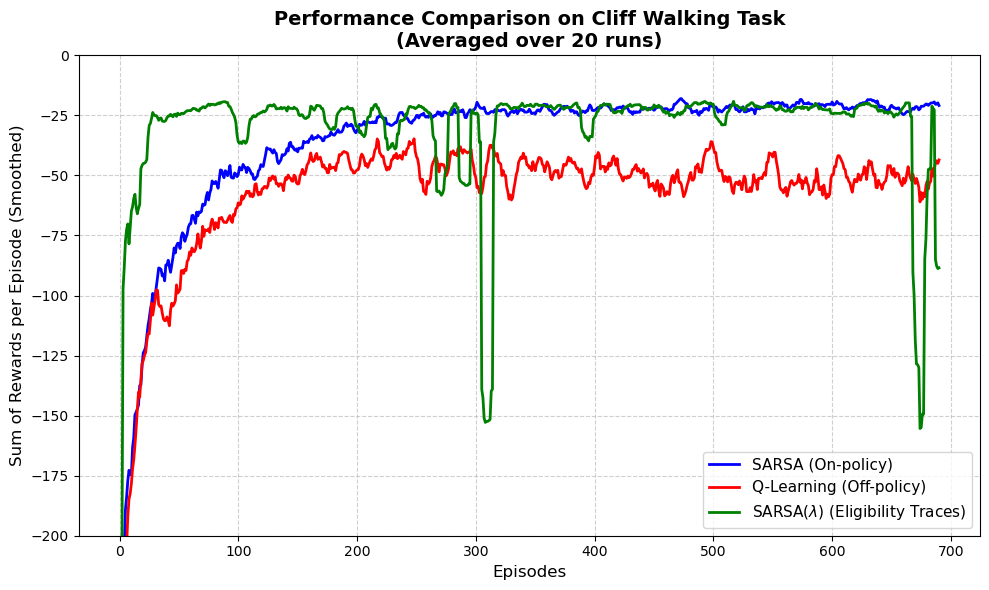

#### 3.3 本章总结

**强化学习算法全景对比**

| 算法 | 类型 | 需要模型 | 更新时机 | 更新目标 | 偏差 | 方差 |
|------|------|---------|---------|---------|------|------|
| 动态规划 | 规划 | 是 | 同步/异步 | $R + \gamma \sum p V$ | 无 | 无 |
| 蒙特卡洛 | 采样 | 否 | 回合结束 | $G_t$ | 无 | 高 |
| TD(0) | 采样+自举 | 否 | 每步 | $R + \gamma V(S')$ | 有 | 低 |
| n-step TD | 采样+自举 | 否 | n 步后 | $\sum \gamma^k R + \gamma^n V$ | 中 | 中 |
| TD(λ) | 采样+自举 | 否 | 每步 | λ-回报 | 可调 | 可调 |
| SARSA | 同策略 | 否 | 每步 | $R + \gamma Q(S', A')$ | 有 | 低 |
| Q-Learning | 异策略 | 否 | 每步 | $R + \gamma \max Q(S', a)$ | 有 | 低 |

---

**三条核心主线**

**1. 有模型 vs 无模型**

$$\text{DP（精确期望）} \xrightarrow{\text{去掉模型}} \text{MC/TD（采样估计）}$$

- 有模型（DP）：数据效率高，但需要完美模型
- 无模型（MC/TD）：不需要模型，但需要大量交互

**2. 偏差-方差权衡**

$$\text{MC（无偏高方差）} \xleftarrow[\lambda \in (0,1)]{\text{TD(λ) 平滑插值}} \xrightarrow{} \text{TD(0)（有偏低方差）}$$

- MC：看完整轨迹，无偏但高方差
- TD(0)：只看一步，有偏但低方差
- n-step TD / TD(λ)：在两者之间平滑调节

**3. 同策略 vs 异策略**

$$\text{SARSA（保守安全）} \xleftrightarrow{\text{探索风险的处理方式}} \text{Q-Learning（激进最优）}$$

- SARSA：评估时考虑探索风险，学到的是"带着手套开车"的安全策略
- Q-Learning：评估时假设完美执行，学到的是理论最优策略
